# Reputation-Weighted Aggregation vs Capital-Weighted Aggregation
## Under Heterogeneous Stakes, Heavy-Tailed Outcomes, and Heterogeneous Private Signals

**Research Question:**  
Does reputation-weighted aggregation improve forecast calibration vs capital-weighted aggregation when agents have heterogeneous wealth (stakes) and heterogeneous signal quality?

This notebook compares three aggregation mechanisms:
1. **Equal-weighted** (naive crowd): $\bar{p}_j = \frac{1}{N}\sum_i p_{i,j}$
2. **Capital-weighted** (stake-only): $p_j^C = \frac{\sum_i s_i \, p_{i,j}}{\sum_i s_i}$
3. **Reputation-weighted** (proposed): $p_j^R = \frac{\sum_i r_i \, s_i \, p_{i,j}}{\sum_i r_i \, s_i}$

We test under three **wealth--skill correlation regimes**:
- **A) Uncorrelated**: stakes independent of agent quality
- **B) Anti-correlated** (hard case): whales tend to be noisy agents
- **C) Correlated** (sanity check): whales tend to be skilled agents

> **Terminology note:** The aggregation mechanism is an *LMSR-inspired stake-weighted probability aggregator*. Full LMSR with cost functions and sequential trading is reserved for future work.

## B. Model Overview

**Pipeline for each round $j = 1, \dots, J$:**

1. **Latent quality**: $q_j \sim \text{Pareto}(\alpha)$
2. **True breakout probability**: $\theta_j = \sigma(\beta \log q_j + b)$
3. **Private signals**: $x_{i,j} = \text{logit}(\theta_j) + \epsilon_{i,j}$, $\;\epsilon_{i,j} \sim \mathcal{N}(0, \sigma_i^2)$
4. **Belief**: $p_{i,j} = \sigma(x_{i,j})$
5. **Aggregation** (LMSR-inspired):
   - Equal: $\bar{p}_j = \frac{1}{N}\sum_i p_{i,j}$
   - Capital: $p_j^C = \frac{\sum_i s_i p_{i,j}}{\sum_i s_i}$
   - Reputation: $p_j^R = \frac{\sum_i r_i s_i p_{i,j}}{\sum_i r_i s_i}$
6. **Outcome**: $Y_j \sim \text{Bernoulli}(\theta_j)$
7. **Scoring**: Brier score and log loss
8. **Reputation update**: $r_i \leftarrow (1-\lambda) r_i + \lambda \exp(-k (p_{i,j} - Y_j)^2)$

**Stakes**: $s_i \sim \text{LogNormal}(0, \sigma_s^2)$, normalized so $\text{mean}(s) = 1$. Assigned to agents under one of three wealth--skill correlation regimes.

### Full LMSR Reference (not implemented --- future work)

$$C(q_0, q_1) = b\log(e^{q_0/b} + e^{q_1/b}), \quad p = \frac{e^{q_1/b}}{e^{q_0/b} + e^{q_1/b}}$$

## C. Imports and Helpers

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from scipy.optimize import brentq
from scipy import stats
import time

TUNE_SEED = 42


def sigmoid(x):
    """Numerically stable sigmoid."""
    return np.where(x >= 0, 1.0 / (1.0 + np.exp(-x)), np.exp(x) / (1.0 + np.exp(x)))


def logit(p):
    """Numerically stable logit."""
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return np.log(p / (1 - p))


def tune_bias(alpha, beta=1.0, target=0.10, seed=TUNE_SEED):
    """Find bias b so that E[theta] ~ target."""
    rng_t = np.random.default_rng(seed)
    q = rng_t.pareto(alpha, size=200_000) + 1
    return brentq(lambda bv: sigmoid(beta * np.log(q) + bv).mean() - target, -15, 15)


def calibration_curve(predictions, outcomes, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    centers, freqs, counts = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (predictions >= lo) & (predictions < hi)
        if m.sum() > 0:
            centers.append(predictions[m].mean())
            freqs.append(outcomes[m].mean())
            counts.append(m.sum())
        else:
            centers.append((lo + hi) / 2); freqs.append(np.nan); counts.append(0)
    return np.array(centers), np.array(freqs), np.array(counts)


def rolling_mean(arr, w):
    cs = np.cumsum(arr)
    cs = np.insert(cs, 0, 0)
    return (cs[w:] - cs[:-w]) / w


def bootstrap_ci(values, n_boot=10000, ci=0.95, seed=999):
    rng_b = np.random.default_rng(seed)
    n = len(values)
    boots = np.array([rng_b.choice(values, size=n, replace=True).mean() for _ in range(n_boot)])
    a = (1 - ci) / 2
    return np.percentile(boots, a * 100), np.percentile(boots, (1 - a) * 100)


def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'n.s.'


print("Helpers loaded.")

Helpers loaded.


## D. Parameters

In [2]:
N = 50
J = 5000
ALPHA = 1.7
BETA = 1.0
TARGET_BASE_RATE = 0.10

FRAC_GOOD = 0.2
SIGMA_GOOD = 0.6
SIGMA_BAD = 1.6

REP_INIT = 1.0
LAMBDA = 0.05
K = 5.0

SIGMA_S = 1.0  # LogNormal stake scale

N_SEEDS_MAIN = 30
N_SEEDS_SWEEP = 10

SWEEP_J = 2000
SWEEP_ALPHAS = [1.3, 1.7, 2.5]
SWEEP_NOISE_GAPS = [0.5, 1.0, 1.5]

n_good = int(N * FRAC_GOOD)
n_bad = N - n_good
B = tune_bias(ALPHA, BETA, TARGET_BASE_RATE)

print(f"Agents: {n_good} good (sigma={SIGMA_GOOD}), {n_bad} bad (sigma={SIGMA_BAD})")
print(f"J={J}, alpha={ALPHA}, b={B:.4f}, sigma_s={SIGMA_S}")
print(f"Seeds: {N_SEEDS_MAIN} (main), {N_SEEDS_SWEEP} (sweep)")

Agents: 10 good (sigma=0.6), 40 bad (sigma=1.6)
J=5000, alpha=1.7, b=-2.9333, sigma_s=1.0
Seeds: 30 (main), 10 (sweep)


## E. Stake Generation and Wealth--Skill Regimes

Stake stats: mean=1.00, median=0.82, max=5.86, top20%/bot80%=0.79


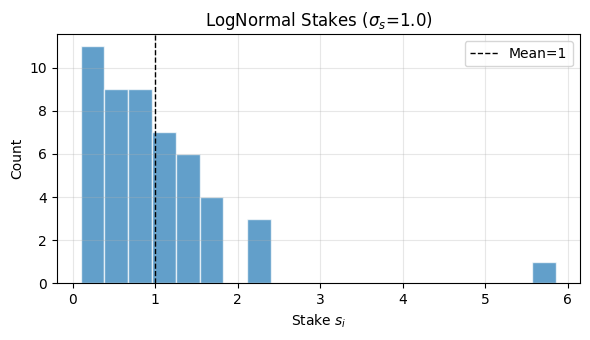

In [3]:
def generate_stakes(n, sigma_s, seed=0):
    """LogNormal stakes, normalized to mean=1."""
    rng = np.random.default_rng(seed)
    raw = rng.lognormal(mean=0, sigma=sigma_s, size=n)
    return raw / raw.mean()


def assign_stakes_regime(stakes, n_good, regime='uncorrelated', seed=0):
    """Assign stakes to agent types under a wealth-skill correlation regime.
    
    Returns reordered stakes: indices 0..n_good-1 = good agents.
    Regimes:
      uncorrelated (A): random shuffle
      anti_correlated (B): top stakes -> bad agents (80% prob)
      correlated (C): top stakes -> good agents (80% prob)
    """
    rng = np.random.default_rng(seed + 7777)
    n = len(stakes)
    n_bad = n - n_good
    sorted_idx = np.argsort(stakes)[::-1]  # descending
    
    if regime == 'uncorrelated':
        perm = rng.permutation(n)
        good_indices = set(perm[:n_good])
    elif regime == 'anti_correlated':
        good_slots, bad_slots = n_good, n_bad
        good_indices = set()
        for idx in sorted_idx:
            if bad_slots == 0:
                good_indices.add(idx); good_slots -= 1
            elif good_slots == 0:
                bad_slots -= 1
            elif rng.random() < 0.8:
                bad_slots -= 1
            else:
                good_indices.add(idx); good_slots -= 1
    elif regime == 'correlated':
        good_slots, bad_slots = n_good, n_bad
        good_indices = set()
        for idx in sorted_idx:
            if good_slots == 0:
                bad_slots -= 1
            elif bad_slots == 0:
                good_indices.add(idx); good_slots -= 1
            elif rng.random() < 0.8:
                good_indices.add(idx); good_slots -= 1
            else:
                bad_slots -= 1
    else:
        raise ValueError(f"Unknown regime: {regime}")
    
    good_list = sorted(good_indices)
    bad_list = sorted(set(range(n)) - good_indices)
    return np.concatenate([stakes[good_list], stakes[bad_list]])


# Demo stake distribution
demo_stakes_raw = generate_stakes(N, SIGMA_S, seed=42)
top20 = np.sort(demo_stakes_raw)[-N//5:].sum()
bot80 = np.sort(demo_stakes_raw)[:N*4//5].sum()
print(f"Stake stats: mean={demo_stakes_raw.mean():.2f}, median={np.median(demo_stakes_raw):.2f}, "
      f"max={demo_stakes_raw.max():.2f}, top20%/bot80%={top20/bot80:.2f}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(demo_stakes_raw, bins=20, alpha=0.7, color='#1f77b4', edgecolor='white')
ax.axvline(1.0, color='k', ls='--', lw=1, label='Mean=1')
ax.set_xlabel('Stake $s_i$'); ax.set_ylabel('Count')
ax.set_title(f'LogNormal Stakes ($\\sigma_s$={SIGMA_S})')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## F. Simulation Engine (3 mechanisms)

In [4]:
def run_simulation(
    N, J, alpha, beta, b, agent_sigmas, stakes,
    rep_init=1.0, lam=0.05, k=5.0, seed=0,
    return_timeseries=False,
):
    """Run one sim with equal/capital/reputation aggregation."""
    rng_sim = np.random.default_rng(seed)
    n_ag = len(agent_sigmas)
    n_g = (agent_sigmas < (agent_sigmas.min() + agent_sigmas.max()) / 2).sum()
    eps = 1e-6
    s_sum = stakes.sum()
    
    pE = np.zeros(J)
    pC = np.zeros(J)
    pR = np.zeros(J)
    brier_E = np.zeros(J)
    brier_C = np.zeros(J)
    brier_R = np.zeros(J)
    ll_E = np.zeros(J)
    ll_C = np.zeros(J)
    ll_R = np.zeros(J)
    thetas = np.zeros(J)
    outcomes = np.zeros(J, dtype=np.int8)
    reps = np.full(n_ag, rep_init)
    
    for j in range(J):
        q_j = rng_sim.pareto(alpha) + 1
        theta_j = float(sigmoid(beta * np.log(q_j) + b))
        thetas[j] = theta_j
        
        p_ij = sigmoid(logit(theta_j) + rng_sim.normal(0, agent_sigmas))
        
        pE[j] = p_ij.mean()
        pC[j] = np.dot(stakes, p_ij) / s_sum
        w_R = reps * stakes
        pR[j] = np.dot(w_R, p_ij) / w_R.sum()
        
        Y_j = rng_sim.binomial(1, theta_j)
        outcomes[j] = Y_j
        
        for ba, la, pv in [(brier_E, ll_E, pE[j]),
                           (brier_C, ll_C, pC[j]),
                           (brier_R, ll_R, pR[j])]:
            ba[j] = (pv - Y_j) ** 2
            pc = np.clip(pv, eps, 1 - eps)
            la[j] = -(Y_j * np.log(pc) + (1 - Y_j) * np.log(1 - pc))
        
        reps = (1 - lam) * reps + lam * np.exp(-k * (p_ij - Y_j) ** 2)
    
    mbE, mbC, mbR = brier_E.mean(), brier_C.mean(), brier_R.mean()
    mlE, mlC, mlR = ll_E.mean(), ll_C.mean(), ll_R.mean()
    
    res = {
        'mean_brier_E': mbE, 'mean_brier_C': mbC, 'mean_brier_R': mbR,
        'mean_ll_E': mlE, 'mean_ll_C': mlC, 'mean_ll_R': mlR,
        'impr_R_vs_C_brier': (mbC - mbR) / mbC * 100,
        'impr_R_vs_C_ll':    (mlC - mlR) / mlC * 100,
        'impr_R_vs_E_brier': (mbE - mbR) / mbE * 100,
        'impr_R_vs_E_ll':    (mlE - mlR) / mlE * 100,
        'impr_C_vs_E_brier': (mbE - mbC) / mbE * 100,
        'impr_C_vs_E_ll':    (mlE - mlC) / mlE * 100,
        'rep_mean_good': reps[:n_g].mean(),
        'rep_mean_bad': reps[n_g:].mean(),
        'rep_separation': reps[:n_g].mean() / reps[n_g:].mean(),
    }
    if return_timeseries:
        res.update({'thetas': thetas, 'outcomes': outcomes,
                    'pE': pE, 'pC': pC, 'pR': pR,
                    'brier_E': brier_E, 'brier_C': brier_C, 'brier_R': brier_R,
                    'reputations': reps.copy()})
    return res


def run_multiseed_regime(
    N, J, alpha, beta, b, sigma_good, sigma_bad, frac_good,
    sigma_s, regime, seeds,
    rep_init=1.0, lam=0.05, k=5.0,
):
    """Multi-seed for one regime. Returns DataFrame."""
    ng = int(N * frac_good)
    agent_sigmas = np.array([sigma_good] * ng + [sigma_bad] * (N - ng))
    rows = []
    for s in seeds:
        raw = generate_stakes(N, sigma_s, seed=s)
        assigned = assign_stakes_regime(raw, ng, regime=regime, seed=s)
        res = run_simulation(
            N=N, J=J, alpha=alpha, beta=beta, b=b,
            agent_sigmas=agent_sigmas, stakes=assigned,
            rep_init=rep_init, lam=lam, k=k, seed=s,
        )
        res['seed'] = s
        res['regime'] = regime
        res['stake_mean_good'] = assigned[:ng].mean()
        res['stake_mean_bad'] = assigned[ng:].mean()
        rows.append(res)
    return pd.DataFrame(rows)


print("Simulation engine loaded.")

Simulation engine loaded.


---
## G. Single-Seed Demonstration (Regime B: Anti-Correlated)

Illustrative run showing the hardest case: whales are noisy.

In [5]:
demo_sigmas = np.array([SIGMA_GOOD] * n_good + [SIGMA_BAD] * n_bad)
demo_raw = generate_stakes(N, SIGMA_S, seed=42)
demo_stakes = assign_stakes_regime(demo_raw, n_good, regime='anti_correlated', seed=42)

demo = run_simulation(
    N=N, J=J, alpha=ALPHA, beta=BETA, b=B,
    agent_sigmas=demo_sigmas, stakes=demo_stakes,
    rep_init=REP_INIT, lam=LAMBDA, k=K, seed=42,
    return_timeseries=True,
)

print(f"Demo (seed=42, regime=B anti-correlated):")
print(f"  Good agents mean stake: {demo_stakes[:n_good].mean():.3f}")
print(f"  Bad agents  mean stake: {demo_stakes[n_good:].mean():.3f}")
print(f"  Brier  -- E:{demo['mean_brier_E']:.6f}  C:{demo['mean_brier_C']:.6f}  R:{demo['mean_brier_R']:.6f}")
print(f"  R vs C Brier: {demo['impr_R_vs_C_brier']:+.3f}%")
print(f"  C vs E Brier: {demo['impr_C_vs_E_brier']:+.3f}% (negative = capital worse than equal)")

Demo (seed=42, regime=B anti-correlated):
  Good agents mean stake: 1.797
  Bad agents  mean stake: 0.801
  Brier  -- E:0.088912  C:0.088092  R:0.087923
  R vs C Brier: +0.192%
  C vs E Brier: +0.921% (negative = capital worse than equal)


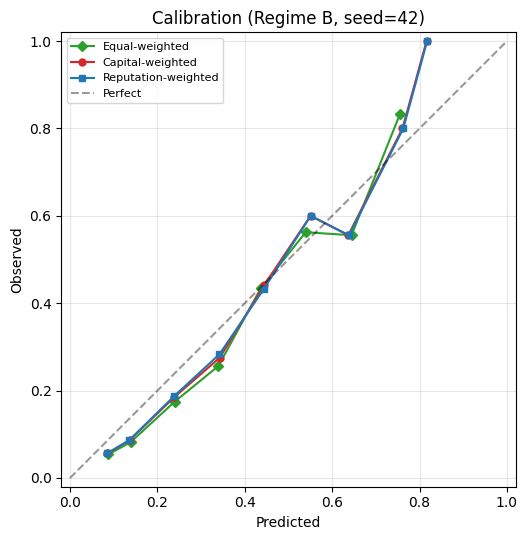

In [6]:
# --- Calibration ---
fig, ax = plt.subplots(figsize=(5.5, 5.5))
for preds, label, color, marker in [
    (demo['pE'], 'Equal-weighted', '#2ca02c', 'D'),
    (demo['pC'], 'Capital-weighted', '#d62728', 'o'),
    (demo['pR'], 'Reputation-weighted', '#1f77b4', 's'),
]:
    c, f, _ = calibration_curve(preds, demo['outcomes'])
    ax.plot(c, f, f'{marker}-', color=color, label=label, ms=5)
ax.plot([0,1],[0,1], 'k--', alpha=0.4, label='Perfect')
ax.set_xlabel('Predicted'); ax.set_ylabel('Observed')
ax.set_title('Calibration (Regime B, seed=42)')
ax.legend(fontsize=8); ax.set_xlim(-0.02,1.02); ax.set_ylim(-0.02,1.02)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

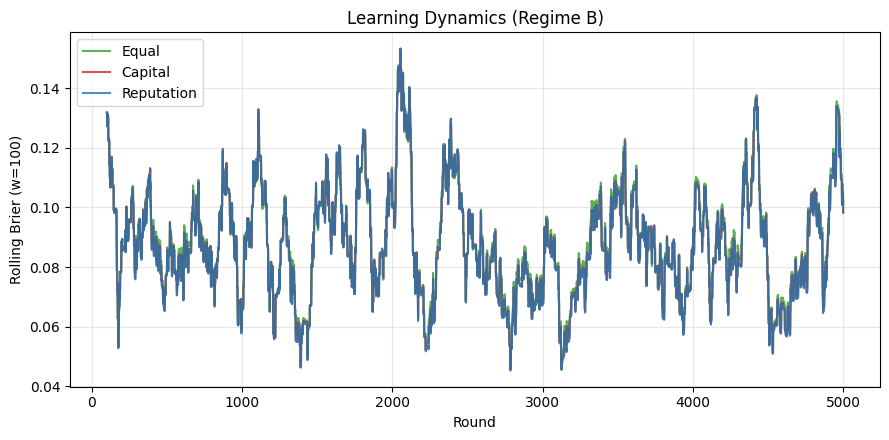

In [7]:
# --- Learning Dynamics ---
W = 100
rx = np.arange(W, J + 1)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(rx, rolling_mean(demo['brier_E'], W), color='#2ca02c', alpha=0.8, label='Equal')
ax.plot(rx, rolling_mean(demo['brier_C'], W), color='#d62728', alpha=0.8, label='Capital')
ax.plot(rx, rolling_mean(demo['brier_R'], W), color='#1f77b4', alpha=0.8, label='Reputation')
ax.set_xlabel('Round'); ax.set_ylabel(f'Rolling Brier (w={W})')
ax.set_title('Learning Dynamics (Regime B)'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

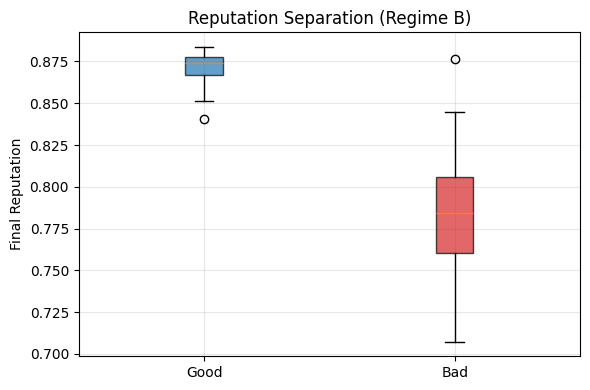

Good: 0.8691, Bad: 0.7825, Ratio: 1.111x


In [8]:
# --- Reputation Separation ---
reps_demo = demo['reputations']
fig, ax = plt.subplots(figsize=(6, 4))
bp = ax.boxplot([reps_demo[:n_good], reps_demo[n_good:]], tick_labels=['Good', 'Bad'], patch_artist=True)
bp['boxes'][0].set_facecolor('#1f77b4'); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#d62728'); bp['boxes'][1].set_alpha(0.7)
ax.set_ylabel('Final Reputation'); ax.set_title('Reputation Separation (Regime B)')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f"Good: {reps_demo[:n_good].mean():.4f}, Bad: {reps_demo[n_good:].mean():.4f}, "
      f"Ratio: {reps_demo[:n_good].mean()/reps_demo[n_good:].mean():.3f}x")

---
## H. Multi-Seed Main Results: All Three Regimes

30 seeds each, J=5000. We compare Equal vs Capital vs Reputation under regimes A, B, C.

In [9]:
main_seeds = list(range(N_SEEDS_MAIN))
REGIMES = ['uncorrelated', 'anti_correlated', 'correlated']
REGIME_LABELS = {'uncorrelated': 'A: Uncorrelated',
                 'anti_correlated': 'B: Anti-correlated',
                 'correlated': 'C: Correlated'}

regime_dfs = {}
t0 = time.time()
for regime in REGIMES:
    regime_dfs[regime] = run_multiseed_regime(
        N=N, J=J, alpha=ALPHA, beta=BETA, b=B,
        sigma_good=SIGMA_GOOD, sigma_bad=SIGMA_BAD, frac_good=FRAC_GOOD,
        sigma_s=SIGMA_S, regime=regime, seeds=main_seeds,
        rep_init=REP_INIT, lam=LAMBDA, k=K,
    )
elapsed = time.time() - t0
print(f"Main runs: 3 regimes x {N_SEEDS_MAIN} seeds x {J} rounds in {elapsed:.1f}s")

Main runs: 3 regimes x 30 seeds x 5000 rounds in 13.5s


In [10]:
# --- Key findings ---
print("=" * 76)
print("KEY FINDINGS (alpha=1.7, noise_gap=1.0, sigma_s=1.0, J=5000)")
print("=" * 76)
for regime in REGIMES:
    df = regime_dfs[regime]
    label = REGIME_LABELS[regime]
    print(f"\n{label}:")
    print(f"  Mean stakes -- good: {df['stake_mean_good'].mean():.3f}, bad: {df['stake_mean_bad'].mean():.3f}")
    for mname, col in [('Brier', 'impr_R_vs_C_brier'), ('LogLoss', 'impr_R_vs_C_ll')]:
        vals = df[col].values
        ci = bootstrap_ci(vals)
        _, pval = stats.ttest_1samp(vals, 0)
        print(f"  R vs C {mname}: {vals.mean():+.4f}%  CI [{ci[0]:+.4f}, {ci[1]:+.4f}]  p={pval:.2e} {sig_stars(pval)}")
    ce = df['impr_C_vs_E_brier'].values
    print(f"  C vs E Brier:  {ce.mean():+.4f}%  {'(capital hurts)' if ce.mean() < -0.01 else '(capital helps)' if ce.mean() > 0.01 else '(~neutral)'}")
    print(f"  Rep separation: {df['rep_separation'].mean():.3f}x")

KEY FINDINGS (alpha=1.7, noise_gap=1.0, sigma_s=1.0, J=5000)

A: Uncorrelated:
  Mean stakes -- good: 0.992, bad: 1.002
  R vs C Brier: +0.1551%  CI [+0.1433, +0.1663]  p=1.23e-21 ***
  R vs C LogLoss: +0.1518%  CI [+0.1407, +0.1623]  p=4.12e-22 ***
  C vs E Brier:  -0.8340%  (capital hurts)
  Rep separation: 1.105x

B: Anti-correlated:
  Mean stakes -- good: 0.846, bad: 1.039


  R vs C Brier: +0.1385%  CI [+0.1226, +0.1557]  p=4.79e-16 ***
  R vs C LogLoss: +0.1320%  CI [+0.1170, +0.1478]  p=2.39e-16 ***
  C vs E Brier:  -1.2125%  (capital hurts)
  Rep separation: 1.105x

C: Correlated:
  Mean stakes -- good: 2.531, bad: 0.617
  R vs C Brier: +0.1447%  CI [+0.1336, +0.1560]  p=3.53e-21 ***


  R vs C LogLoss: +0.1703%  CI [+0.1606, +0.1797]  p=3.54e-25 ***
  C vs E Brier:  +1.8811%  (capital helps)
  Rep separation: 1.105x


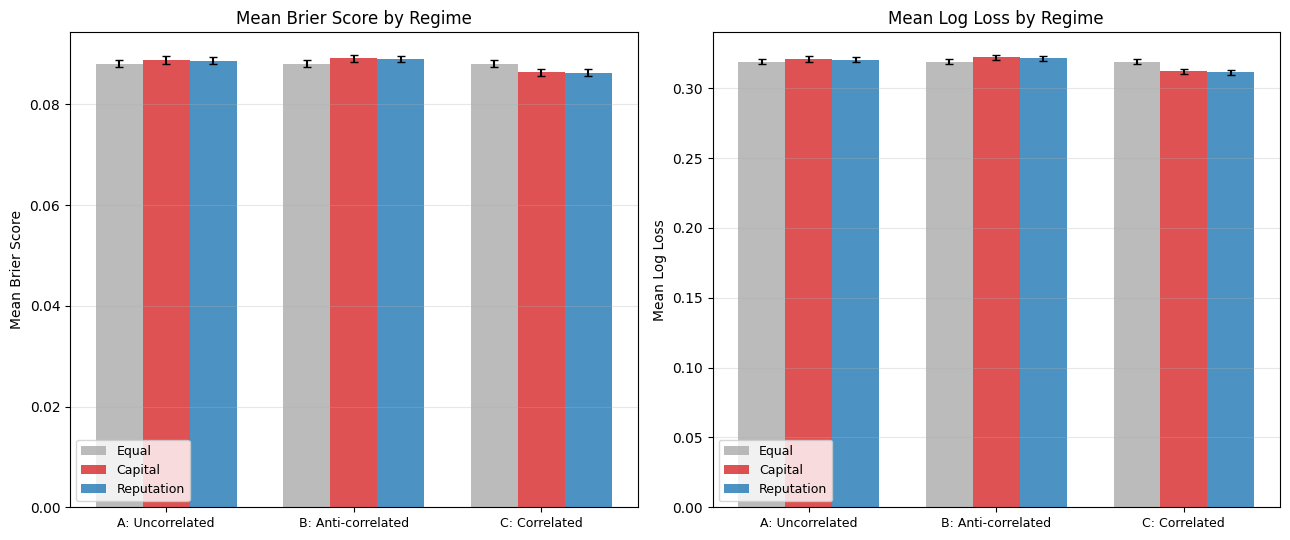

In [11]:
# --- Bar Chart: Equal vs Capital vs Reputation for each regime ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
method_labels = ['Equal', 'Capital', 'Reputation']
method_keys = ['E', 'C', 'R']
method_colors = ['#aaaaaa', '#d62728', '#1f77b4']
x_pos = np.arange(len(REGIMES))
bw = 0.25

for ax, metric, title in zip(axes, ['brier', 'll'], ['Mean Brier Score', 'Mean Log Loss']):
    for i_m, (mk, mc, ml) in enumerate(zip(method_keys, method_colors, method_labels)):
        means, errs = [], []
        for regime in REGIMES:
            vals = regime_dfs[regime][f'mean_{metric}_{mk}'].values
            means.append(vals.mean())
            errs.append(vals.std() / np.sqrt(len(vals)) * 1.96)
        ax.bar(x_pos + i_m * bw, means, bw, yerr=errs, capsize=3,
               color=mc, alpha=0.8, label=ml)
    ax.set_xticks(x_pos + bw)
    ax.set_xticklabels([REGIME_LABELS[r] for r in REGIMES], fontsize=9)
    ax.set_ylabel(title); ax.set_title(title + ' by Regime')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

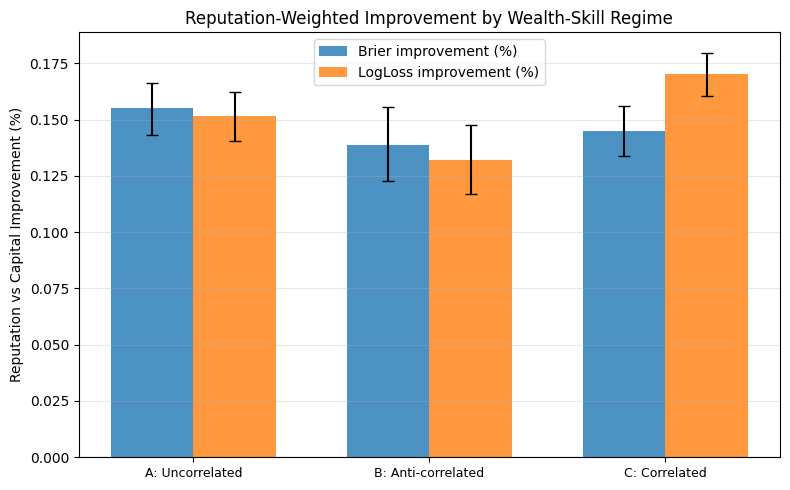

In [12]:
# --- Bar Chart: R vs C improvement by regime ---
fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(len(REGIMES))
bw = 0.35

for i_m, (col, label, color) in enumerate([
    ('impr_R_vs_C_brier', 'Brier', '#1f77b4'),
    ('impr_R_vs_C_ll', 'LogLoss', '#ff7f0e'),
]):
    means, ci_los, ci_his = [], [], []
    for regime in REGIMES:
        vals = regime_dfs[regime][col].values
        m = vals.mean()
        ci = bootstrap_ci(vals)
        means.append(m); ci_los.append(m - ci[0]); ci_his.append(ci[1] - m)
    ax.bar(x_pos + i_m * bw, means, bw,
           yerr=[ci_los, ci_his], capsize=4,
           color=color, alpha=0.8, label=f'{label} improvement (%)')

ax.axhline(0, color='gray', ls='--', lw=0.8)
ax.set_xticks(x_pos + bw / 2)
ax.set_xticklabels([REGIME_LABELS[r] for r in REGIMES], fontsize=9)
ax.set_ylabel('Reputation vs Capital Improvement (%)')
ax.set_title('Reputation-Weighted Improvement by Wealth-Skill Regime')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

---
## I. Parameter Sweep (Regimes A & B)

Sweep over $\alpha \times$ noise gap for regimes A (uncorrelated) and B (anti-correlated), 10 seeds each.

In [13]:
sweep_seeds = list(range(N_SEEDS_SWEEP))
sweep_regimes = ['uncorrelated', 'anti_correlated']
sweep_rows = []

t0 = time.time()
for alpha_val in SWEEP_ALPHAS:
    b_val = tune_bias(alpha_val, BETA, TARGET_BASE_RATE)
    for noise_gap in SWEEP_NOISE_GAPS:
        sbad = SIGMA_GOOD + noise_gap
        for regime in sweep_regimes:
            df = run_multiseed_regime(
                N=N, J=SWEEP_J, alpha=alpha_val, beta=BETA, b=b_val,
                sigma_good=SIGMA_GOOD, sigma_bad=sbad, frac_good=FRAC_GOOD,
                sigma_s=SIGMA_S, regime=regime, seeds=sweep_seeds,
                rep_init=REP_INIT, lam=LAMBDA, k=K,
            )
            for metric, mcol in [('Brier', 'impr_R_vs_C_brier'), ('LogLoss', 'impr_R_vs_C_ll')]:
                vals = df[mcol].values
                ci = bootstrap_ci(vals)
                _, pval = stats.ttest_1samp(vals, 0)
                ce_col = 'impr_C_vs_E_brier' if metric == 'Brier' else 'impr_C_vs_E_ll'
                sweep_rows.append({
                    'alpha': alpha_val, 'noise_gap': noise_gap, 'sigma_bad': sbad,
                    'regime': regime, 'metric': metric,
                    'mean_impr': vals.mean(), 'ci_lo': ci[0], 'ci_hi': ci[1],
                    'p_value': pval, 'sig': sig_stars(pval),
                    'C_vs_E': df[ce_col].mean(),
                    'rep_sep': df['rep_separation'].mean(),
                    'n_seeds': N_SEEDS_SWEEP,
                })

sweep_df = pd.DataFrame(sweep_rows)
elapsed = time.time() - t0
print(f"Sweep: {len(SWEEP_ALPHAS)}x{len(SWEEP_NOISE_GAPS)}x{len(sweep_regimes)} regimes, "
      f"{N_SEEDS_SWEEP} seeds each, {elapsed:.1f}s")

Sweep: 3x3x2 regimes, 10 seeds each, 13.4s


In [14]:
# Display sweep tables
for regime in sweep_regimes:
    sub = sweep_df[sweep_df['regime'] == regime]
    print(f"\n{'='*70}")
    print(f"SWEEP: {REGIME_LABELS[regime]} (J={SWEEP_J}, {N_SEEDS_SWEEP} seeds)")
    print(f"{'='*70}")
    display(sub[['alpha','noise_gap','metric','mean_impr','ci_lo','ci_hi','p_value','sig','C_vs_E','rep_sep']]
            .style.format({
                'mean_impr': '{:+.4f}%', 'ci_lo': '{:+.4f}', 'ci_hi': '{:+.4f}',
                'p_value': '{:.4f}', 'C_vs_E': '{:+.4f}%', 'rep_sep': '{:.3f}',
            }).hide(axis='index'))


SWEEP: A: Uncorrelated (J=2000, 10 seeds)


alpha,noise_gap,metric,mean_impr,ci_lo,ci_hi,p_value,sig,C_vs_E,rep_sep
1.300000,0.500000,Brier,+0.0059%,-0.0030,+0.0150,0.2505,n.s.,-0.2942%,1.040
1.300000,0.500000,LogLoss,+0.0103%,+0.0020,+0.0194,0.0553,n.s.,-0.3102%,1.040
1.300000,1.000000,Brier,+0.1000%,+0.0735,+0.1311,0.0001,***,-0.8753%,1.095
1.300000,1.000000,LogLoss,+0.1088%,+0.0822,+0.1398,0.0001,***,-0.6710%,1.095
1.300000,1.500000,Brier,+0.3725%,+0.3102,+0.4494,0.0000,***,-1.6363%,1.152
1.300000,1.500000,LogLoss,+0.3463%,+0.2867,+0.4174,0.0000,***,-1.0347%,1.152
1.700000,0.500000,Brier,+0.0117%,+0.0029,+0.0193,0.0254,*,-0.4047%,1.047
1.700000,0.500000,LogLoss,+0.0145%,+0.0057,+0.0222,0.0092,**,-0.3908%,1.047
1.700000,1.000000,Brier,+0.1348%,+0.1060,+0.1645,0.0000,***,-1.0423%,1.107
1.700000,1.000000,LogLoss,+0.1317%,+0.1040,+0.1615,0.0000,***,-0.7794%,1.107



SWEEP: B: Anti-correlated (J=2000, 10 seeds)


alpha,noise_gap,metric,mean_impr,ci_lo,ci_hi,p_value,sig,C_vs_E,rep_sep
1.300000,0.500000,Brier,+0.0068%,-0.0002,+0.0137,0.1034,n.s.,-0.4356%,1.040
1.300000,0.500000,LogLoss,+0.0104%,+0.0055,+0.0156,0.0044,**,-0.3287%,1.040
1.300000,1.000000,Brier,+0.1097%,+0.0941,+0.1256,0.0000,***,-0.9405%,1.095
1.300000,1.000000,LogLoss,+0.1155%,+0.0987,+0.1338,0.0000,***,-0.5843%,1.095
1.300000,1.500000,Brier,+0.3983%,+0.3520,+0.4461,0.0000,***,-1.5313%,1.152
1.300000,1.500000,LogLoss,+0.3659%,+0.3161,+0.4162,0.0000,***,-0.8053%,1.152
1.700000,0.500000,Brier,+0.0133%,+0.0088,+0.0170,0.0002,***,-0.4482%,1.047
1.700000,0.500000,LogLoss,+0.0153%,+0.0107,+0.0193,0.0001,***,-0.3587%,1.047
1.700000,1.000000,Brier,+0.1459%,+0.1270,+0.1651,0.0000,***,-0.9848%,1.107
1.700000,1.000000,LogLoss,+0.1389%,+0.1202,+0.1573,0.0000,***,-0.6275%,1.107


## J. Effect Size Scaling

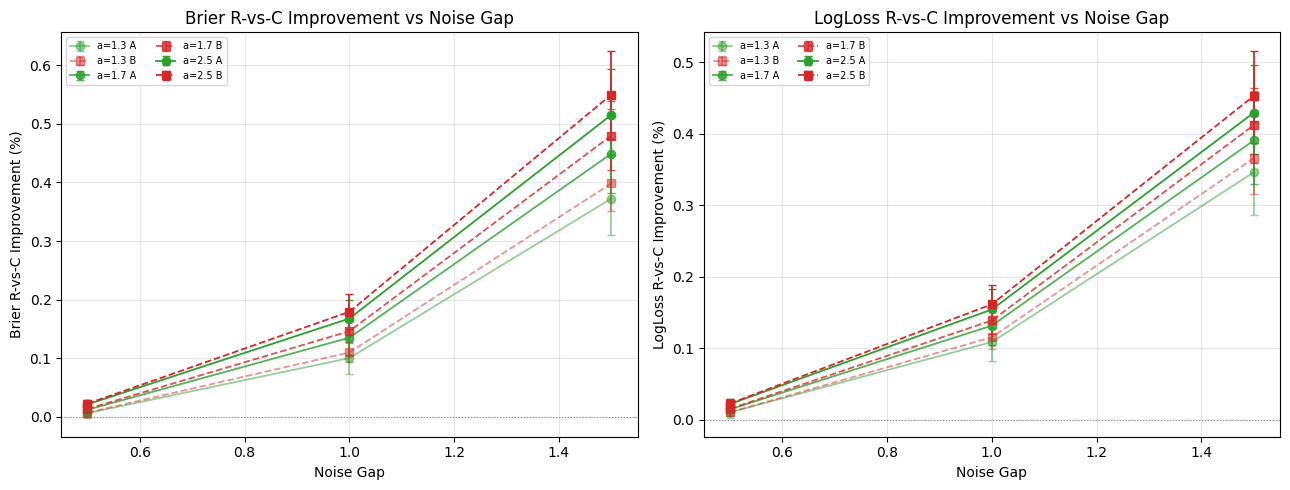

In [15]:
# --- Line Plot: R vs C improvement vs noise gap, by regime ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
regime_styles = {'uncorrelated': ('o', '#2ca02c', '-'), 'anti_correlated': ('s', '#d62728', '--')}

for ax, metric, ylabel in zip(axes, ['Brier', 'LogLoss'],
    ['Brier R-vs-C Improvement (%)', 'LogLoss R-vs-C Improvement (%)']):
    sub_m = sweep_df[sweep_df['metric'] == metric]
    for alpha_val in SWEEP_ALPHAS:
        for regime, (marker, base_color, ls) in regime_styles.items():
            sub = sub_m[(sub_m['alpha'] == alpha_val) & (sub_m['regime'] == regime)]
            sub = sub.sort_values('noise_gap')
            means = sub['mean_impr'].values
            lo = means - sub['ci_lo'].values
            hi = sub['ci_hi'].values - means
            alpha_op = {1.3: 0.5, 1.7: 0.8, 2.5: 1.0}[alpha_val]
            ax.errorbar(sub['noise_gap'].values, means, yerr=[lo, hi],
                        marker=marker, color=base_color, alpha=alpha_op,
                        capsize=3, lw=1.3, ms=6, ls=ls,
                        label=f'a={alpha_val} {REGIME_LABELS[regime][:1]}')
    ax.axhline(0, color='gray', ls=':', lw=0.8)
    ax.set_xlabel('Noise Gap'); ax.set_ylabel(ylabel)
    ax.set_title(ylabel.replace(' (%)', ' vs Noise Gap'))
    ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

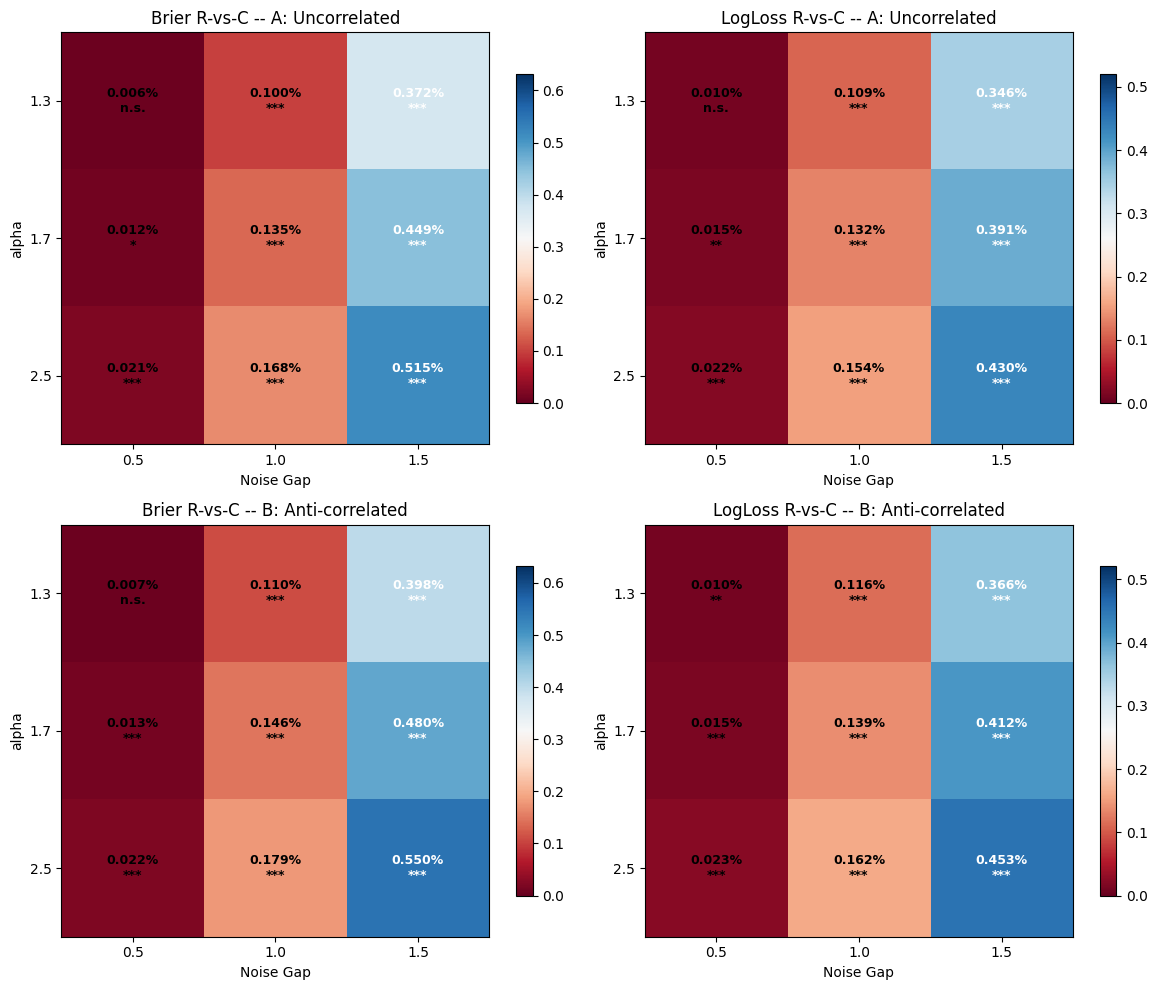

In [16]:
# --- Heatmaps: R vs C Brier improvement for A and B ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i_r, regime in enumerate(sweep_regimes):
    for i_m, (metric, title_m) in enumerate([('Brier', 'Brier'), ('LogLoss', 'LogLoss')]):
        ax = axes[i_r, i_m]
        sub = sweep_df[(sweep_df['regime'] == regime) & (sweep_df['metric'] == metric)]
        pivot = sub.pivot(index='alpha', columns='noise_gap', values='mean_impr')
        data = pivot.values
        
        # Shared vmax across both regimes for comparability
        all_vals = sweep_df[sweep_df['metric'] == metric]['mean_impr'].values
        vmax = max(0.01, all_vals.max() * 1.15)
        vmin = min(0, all_vals.min() * 1.15)
        im = ax.imshow(data, cmap='RdBu', aspect='auto',
                       norm=Normalize(vmin=vmin, vmax=vmax))
        for ii in range(data.shape[0]):
            for jj in range(data.shape[1]):
                row = sub[(sub['alpha'] == pivot.index[ii]) & (sub['noise_gap'] == pivot.columns[jj])]
                txt = f'{data[ii,jj]:.3f}%\n{row["sig"].values[0]}'
                color = 'white' if abs(data[ii,jj]) > vmax * 0.5 else 'black'
                ax.text(jj, ii, txt, ha='center', va='center', fontsize=9, fontweight='bold', color=color)
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([f'{g:.1f}' for g in pivot.columns])
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([f'{a:.1f}' for a in pivot.index])
        ax.set_xlabel('Noise Gap'); ax.set_ylabel('alpha')
        ax.set_title(f'{title_m} R-vs-C -- {REGIME_LABELS[regime]}')
        plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

---
## J2. Inequality Sensitivity: Stake Dispersion Sweep

How does wealth inequality affect aggregation quality?

We sweep $\sigma_s \in \{0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0\}$ with fixed signal parameters.
At $\sigma_s = 0$, all stakes equal 1 (capital-weighted $\equiv$ equal-weighted).
As $\sigma_s$ increases, stake concentration grows and capital-weighted aggregation
becomes increasingly sensitive to whether whales are skilled or noisy.

**Primary regime**: B (anti-correlated) -- whales are noisy.  
**Secondary regime**: A (uncorrelated) -- wealth independent of skill.

In [17]:
# --- Inequality Sensitivity Sweep ---
INEQ_SIGMA_S_VALUES = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]
INEQ_REGIMES = ['anti_correlated', 'uncorrelated']
INEQ_J = 5000
INEQ_N_SEEDS = 20
ineq_seeds = list(range(INEQ_N_SEEDS))

ineq_rows = []
t0 = time.time()
for sigma_s_val in INEQ_SIGMA_S_VALUES:
    for regime in INEQ_REGIMES:
        df = run_multiseed_regime(
            N=N, J=INEQ_J, alpha=ALPHA, beta=BETA, b=B,
            sigma_good=SIGMA_GOOD, sigma_bad=SIGMA_BAD, frac_good=FRAC_GOOD,
            sigma_s=sigma_s_val, regime=regime, seeds=ineq_seeds,
            rep_init=REP_INIT, lam=LAMBDA, k=K,
        )
        # Compute Gini coefficient of stakes for reference
        sample_stakes = generate_stakes(N, sigma_s_val, seed=0)
        sorted_s = np.sort(sample_stakes)
        n_s = len(sorted_s)
        gini = (2 * np.sum((np.arange(1, n_s+1)) * sorted_s) / (n_s * sorted_s.sum()) - (n_s + 1) / n_s)

        for metric, r_col, e_col, brier_key, ll_key in [
            ('Brier', 'impr_R_vs_C_brier', 'impr_C_vs_E_brier', 'mean_brier', 'mean_ll'),
            ('LogLoss', 'impr_R_vs_C_ll', 'impr_C_vs_E_ll', 'mean_brier', 'mean_ll'),
        ]:
            r_vals = df[r_col].values
            e_vals = df[e_col].values
            ci_r = bootstrap_ci(r_vals)
            ci_e = bootstrap_ci(e_vals)
            _, p_r = stats.ttest_1samp(r_vals, 0)
            _, p_e = stats.ttest_1samp(e_vals, 0)

            score_key = 'brier' if metric == 'Brier' else 'll'
            ineq_rows.append({
                'regime': regime,
                'sigma_s': sigma_s_val,
                'metric': metric,
                'J': INEQ_J,
                'n_seeds': INEQ_N_SEEDS,
                'gini': gini,
                'mean_E': df[f'mean_{score_key}_E'].mean(),
                'mean_C': df[f'mean_{score_key}_C'].mean(),
                'mean_R': df[f'mean_{score_key}_R'].mean(),
                'R_vs_C_pct': r_vals.mean(),
                'R_vs_C_ci_lo': ci_r[0],
                'R_vs_C_ci_hi': ci_r[1],
                'R_vs_C_p': p_r,
                'R_vs_C_sig': sig_stars(p_r),
                'C_vs_E_pct': e_vals.mean(),
                'C_vs_E_ci_lo': ci_e[0],
                'C_vs_E_ci_hi': ci_e[1],
                'C_vs_E_p': p_e,
                'C_vs_E_sig': sig_stars(p_e),
                'rep_sep': df['rep_separation'].mean(),
            })
    print(f'  sigma_s={sigma_s_val:.2f} done')

ineq_df = pd.DataFrame(ineq_rows)
elapsed = time.time() - t0
print(f'\nInequality sweep: {len(INEQ_SIGMA_S_VALUES)} sigma_s x '
      f'{len(INEQ_REGIMES)} regimes x {INEQ_N_SEEDS} seeds x {INEQ_J} rounds in {elapsed:.1f}s')

  sigma_s=0.00 done


  sigma_s=0.25 done


  sigma_s=0.50 done


  sigma_s=0.75 done


  sigma_s=1.00 done


  sigma_s=1.25 done


  sigma_s=1.50 done


  sigma_s=1.75 done


  sigma_s=2.00 done

Inequality sweep: 9 sigma_s x 2 regimes x 20 seeds x 5000 rounds in 59.0s


In [18]:
# --- Inequality Sweep Results Table ---
for regime in INEQ_REGIMES:
    sub = ineq_df[ineq_df['regime'] == regime]
    print(f"\n{'='*80}")
    print(f"INEQUALITY SWEEP: {REGIME_LABELS[regime]} (J={INEQ_J}, {INEQ_N_SEEDS} seeds)")
    print(f"{'='*80}")
    display(sub[['sigma_s','metric','gini','mean_E','mean_C','mean_R',
                 'R_vs_C_pct','R_vs_C_ci_lo','R_vs_C_ci_hi','R_vs_C_sig',
                 'C_vs_E_pct','C_vs_E_sig']]
            .style.format({
                'sigma_s': '{:.2f}', 'gini': '{:.3f}',
                'mean_E': '{:.6f}', 'mean_C': '{:.6f}', 'mean_R': '{:.6f}',
                'R_vs_C_pct': '{:+.4f}%', 'R_vs_C_ci_lo': '{:+.4f}', 'R_vs_C_ci_hi': '{:+.4f}',
                'C_vs_E_pct': '{:+.4f}%',
            }).hide(axis='index'))


INEQUALITY SWEEP: B: Anti-correlated (J=5000, 20 seeds)


sigma_s,metric,gini,mean_E,mean_C,mean_R,R_vs_C_pct,R_vs_C_ci_lo,R_vs_C_ci_hi,R_vs_C_sig,C_vs_E_pct,C_vs_E_sig
0.00,Brier,0.000,0.087984,0.087984,0.087866,+0.1344%,+0.1286,+0.1404,***,+0.0000%,n.s.
0.00,LogLoss,0.000,0.319045,0.319045,0.318594,+0.1417%,+0.1366,+0.1467,***,+0.0000%,n.s.
0.25,Brier,0.128,0.087984,0.088075,0.087959,+0.1311%,+0.1236,+0.1385,***,-0.1032%,*
0.25,LogLoss,0.128,0.319045,0.319368,0.318930,+0.1372%,+0.1300,+0.1443,***,-0.1011%,*
0.50,Brier,0.252,0.087984,0.088230,0.088116,+0.1298%,+0.1200,+0.1394,***,-0.2807%,**
0.50,LogLoss,0.252,0.319045,0.319829,0.319401,+0.1338%,+0.1234,+0.1440,***,-0.2460%,*
0.75,Brier,0.366,0.087984,0.088492,0.088376,+0.1313%,+0.1184,+0.1438,***,-0.5795%,***
0.75,LogLoss,0.366,0.319045,0.320533,0.320111,+0.1317%,+0.1179,+0.1450,***,-0.4670%,**
1.00,Brier,0.468,0.087984,0.088921,0.088799,+0.1367%,+0.1194,+0.1539,***,-1.0678%,***
1.00,LogLoss,0.468,0.319045,0.321614,0.321192,+0.1314%,+0.1142,+0.1482,***,-0.8065%,***



INEQUALITY SWEEP: A: Uncorrelated (J=5000, 20 seeds)


sigma_s,metric,gini,mean_E,mean_C,mean_R,R_vs_C_pct,R_vs_C_ci_lo,R_vs_C_ci_hi,R_vs_C_sig,C_vs_E_pct,C_vs_E_sig
0.00,Brier,0.000,0.087984,0.087984,0.087866,+0.1344%,+0.1286,+0.1404,***,+0.0000%,n.s.
0.00,LogLoss,0.000,0.319045,0.319045,0.318594,+0.1417%,+0.1366,+0.1467,***,+0.0000%,n.s.
0.25,Brier,0.128,0.087984,0.088010,0.087891,+0.1361%,+0.1295,+0.1429,***,-0.0300%,n.s.
0.25,LogLoss,0.128,0.319045,0.319132,0.318676,+0.1430%,+0.1373,+0.1487,***,-0.0274%,n.s.
0.50,Brier,0.252,0.087984,0.088110,0.087987,+0.1395%,+0.1309,+0.1479,***,-0.1441%,*
0.50,LogLoss,0.252,0.319045,0.319402,0.318939,+0.1449%,+0.1371,+0.1523,***,-0.1122%,n.s.
0.75,Brier,0.366,0.087984,0.088315,0.088187,+0.1450%,+0.1337,+0.1556,***,-0.3775%,**
0.75,LogLoss,0.366,0.319045,0.319919,0.319448,+0.1473%,+0.1367,+0.1572,***,-0.2747%,*
1.00,Brier,0.468,0.087984,0.088676,0.088541,+0.1530%,+0.1379,+0.1671,***,-0.7881%,**
1.00,LogLoss,0.468,0.319045,0.320789,0.320307,+0.1504%,+0.1362,+0.1636,***,-0.5476%,**


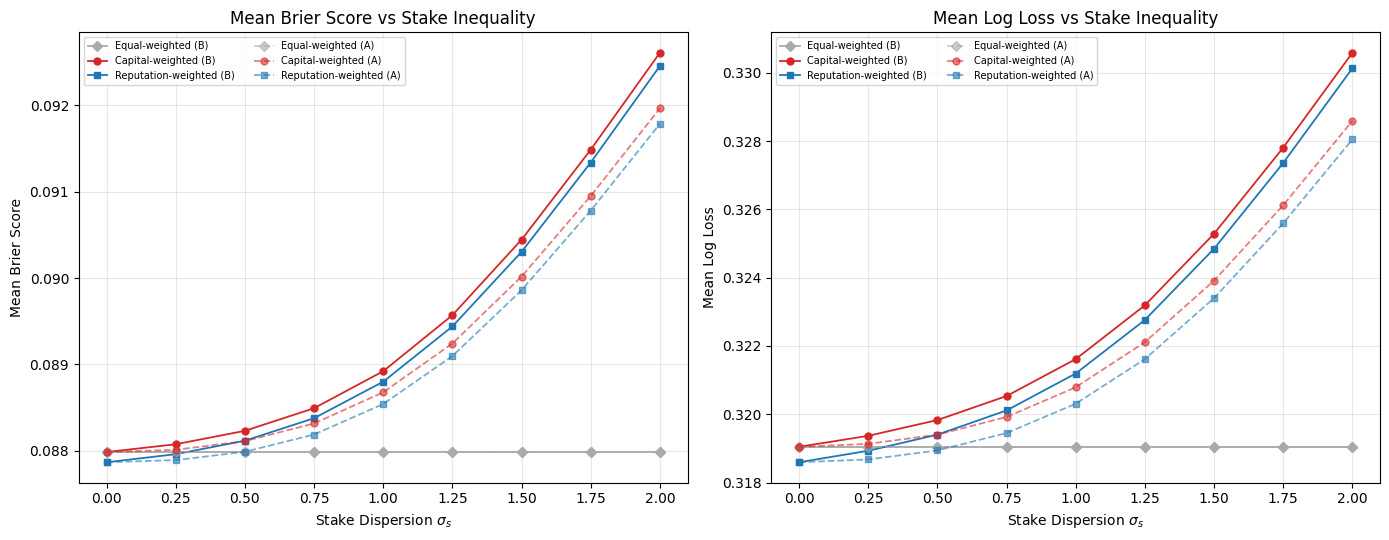

In [19]:
# --- Plot A: Absolute Brier/LogLoss for E, C, R vs sigma_s ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
method_specs = [
    ('mean_E', 'Equal-weighted', '#aaaaaa', 'D', '-'),
    ('mean_C', 'Capital-weighted', '#d62728', 'o', '--'),
    ('mean_R', 'Reputation-weighted', '#1f77b4', 's', '-'),
]

for ax_i, (metric, ylabel) in enumerate([('Brier', 'Mean Brier Score'), ('LogLoss', 'Mean Log Loss')]):
    ax = axes[ax_i]
    for regime, (ls_r, alpha_r) in [('anti_correlated', ('-', 1.0)), ('uncorrelated', ('--', 0.6))]:
        sub = ineq_df[(ineq_df['regime'] == regime) & (ineq_df['metric'] == metric)]
        sub = sub.sort_values('sigma_s')
        xs = sub['sigma_s'].values
        for col, label, color, marker, _ in method_specs:
            full_label = f'{label} ({REGIME_LABELS[regime][:1]})'
            ax.plot(xs, sub[col].values, marker=marker, color=color,
                    alpha=alpha_r, ms=5, lw=1.3, ls=ls_r, label=full_label)
    ax.set_xlabel(r'Stake Dispersion $\sigma_s$')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} vs Stake Inequality')
    ax.legend(fontsize=7, ncol=2, loc='upper left')
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

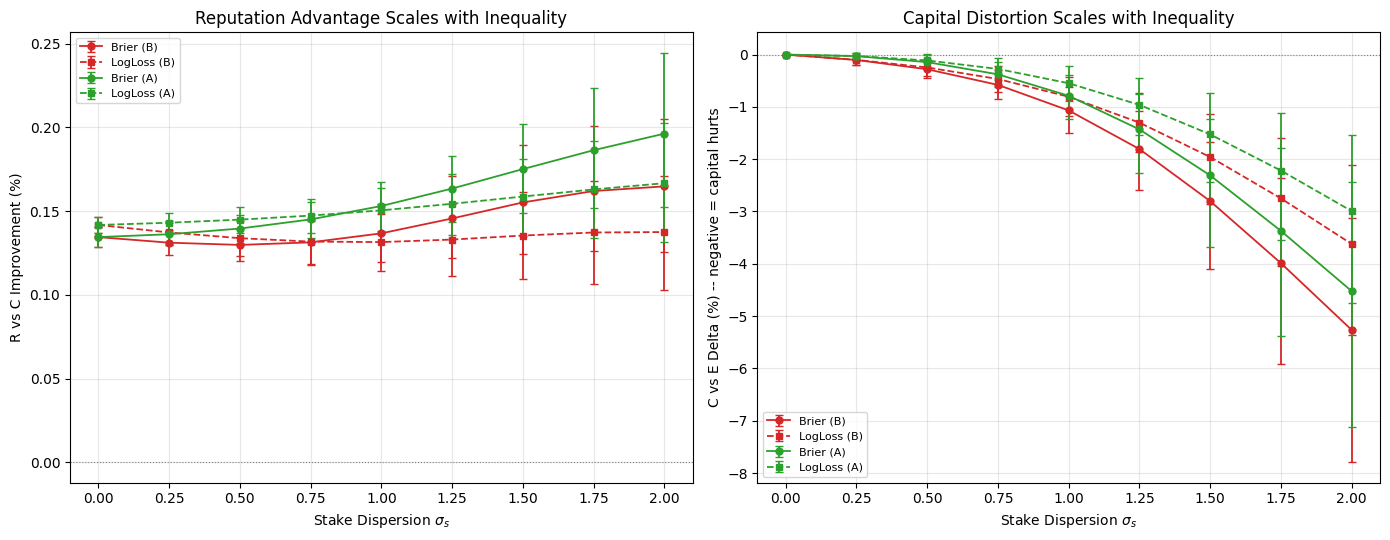

In [20]:
# --- Plot B: R-vs-C Improvement and C-vs-E Distortion vs sigma_s ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
regime_colors = {'anti_correlated': '#d62728', 'uncorrelated': '#2ca02c'}

# Left panel: R vs C improvement
ax = axes[0]
for regime in INEQ_REGIMES:
    for metric, marker, ls in [('Brier', 'o', '-'), ('LogLoss', 's', '--')]:
        sub = ineq_df[(ineq_df['regime'] == regime) & (ineq_df['metric'] == metric)]
        sub = sub.sort_values('sigma_s')
        xs = sub['sigma_s'].values
        ys = sub['R_vs_C_pct'].values
        lo = ys - sub['R_vs_C_ci_lo'].values
        hi = sub['R_vs_C_ci_hi'].values - ys
        ax.errorbar(xs, ys, yerr=[lo, hi], marker=marker, color=regime_colors[regime],
                    capsize=3, lw=1.3, ms=5, ls=ls,
                    label=f'{metric} ({REGIME_LABELS[regime][:1]})')
ax.axhline(0, color='gray', ls=':', lw=0.8)
ax.set_xlabel(r'Stake Dispersion $\sigma_s$')
ax.set_ylabel('R vs C Improvement (%)')
ax.set_title('Reputation Advantage Scales with Inequality')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Right panel: C vs E distortion
ax = axes[1]
for regime in INEQ_REGIMES:
    for metric, marker, ls in [('Brier', 'o', '-'), ('LogLoss', 's', '--')]:
        sub = ineq_df[(ineq_df['regime'] == regime) & (ineq_df['metric'] == metric)]
        sub = sub.sort_values('sigma_s')
        xs = sub['sigma_s'].values
        ys = sub['C_vs_E_pct'].values
        lo = ys - sub['C_vs_E_ci_lo'].values
        hi = sub['C_vs_E_ci_hi'].values - ys
        ax.errorbar(xs, ys, yerr=[lo, hi], marker=marker, color=regime_colors[regime],
                    capsize=3, lw=1.3, ms=5, ls=ls,
                    label=f'{metric} ({REGIME_LABELS[regime][:1]})')
ax.axhline(0, color='gray', ls=':', lw=0.8)
ax.set_xlabel(r'Stake Dispersion $\sigma_s$')
ax.set_ylabel('C vs E Delta (%) -- negative = capital hurts')
ax.set_title('Capital Distortion Scales with Inequality')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

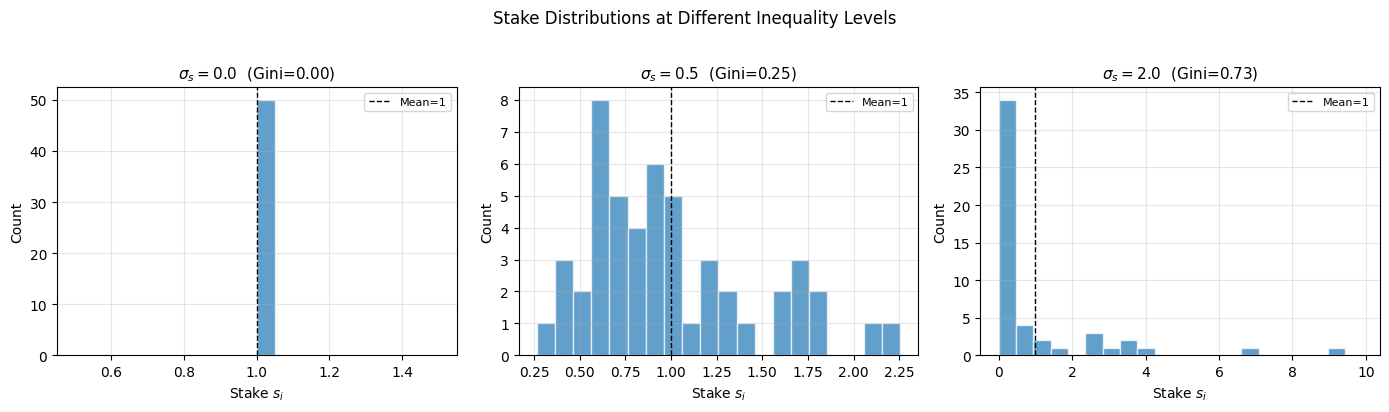

In [21]:
# --- Plot C: Stake distribution examples for sigma_s = 0.5 vs 2.0 ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
example_sigmas = [0.0, 0.5, 2.0]
for ax, ss in zip(axes, example_sigmas):
    stakes_ex = generate_stakes(N, ss, seed=0)
    ax.hist(stakes_ex, bins=20, alpha=0.7, color='#1f77b4', edgecolor='white')
    ax.axvline(1.0, color='k', ls='--', lw=1, label='Mean=1')
    gini_ex = (2 * np.sum(np.arange(1, N+1) * np.sort(stakes_ex)) / (N * stakes_ex.sum()) - (N+1)/N)
    ax.set_title(f'$\\sigma_s = {ss}$  (Gini={gini_ex:.2f})', fontsize=11)
    ax.set_xlabel('Stake $s_i$'); ax.set_ylabel('Count')
    if ss == 2.0:
        ax.set_xlim(-0.5, min(stakes_ex.max() * 1.1, 20))
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle('Stake Distributions at Different Inequality Levels', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

In [22]:
# --- Export inequality sweep results ---
out_dir = '/Users/oakgroup/Desktop/scenius/research'
ineq_df.to_csv(f'{out_dir}/inequality_sweep_results.csv', index=False)
print(f'Exported: {out_dir}/inequality_sweep_results.csv')
print(f'  {len(ineq_df)} rows: {len(INEQ_SIGMA_S_VALUES)} sigma_s x {len(INEQ_REGIMES)} regimes x 2 metrics')

Exported: /Users/oakgroup/Desktop/scenius/research/inequality_sweep_results.csv
  36 rows: 9 sigma_s x 2 regimes x 2 metrics


### J2 Discussion: Limitations and design proposition

Reputation-weighting improves calibration over capital-weighting at every level of stake inequality, but **the gain is modest**. Under high $\sigma_s$, capital-weighting degrades calibration by several percentage points vs equal-weighting, while reputation recovers only a small fraction of that loss. Reputation is a multiplicative correction on stakes and cannot overcome extreme concentration.

**Design question:** Should reputation be applied **multiplicatively** (as here), **replace** stakes entirely, or **compress** the role of stake size? We propose evaluating **log-scaled stakes** (e.g. weight $= r_i \cdot \log(1 + s_i)$ or $\log(1 + r_i s_i)$) alongside these options. With diminishing returns to stake size, reputation can have more bite without fully abandoning skin-in-the-game. Future work: compare (1) multiplicative $r \times s$, (2) reputation-only weighting, and (3) **reputation $\times$ log-scaled stake**.

---
## K. Paper-Ready Results Summary

In [23]:
paper_rows = []
for regime in REGIMES:
    df = regime_dfs[regime]
    for metric, mcol, ecol in [
        ('Brier', 'impr_R_vs_C_brier', 'impr_C_vs_E_brier'),
        ('LogLoss', 'impr_R_vs_C_ll', 'impr_C_vs_E_ll'),
    ]:
        vals = df[mcol].values
        ci = bootstrap_ci(vals)
        _, pval = stats.ttest_1samp(vals, 0)
        ce = df[ecol].values
        paper_rows.append({
            'Regime': REGIME_LABELS[regime],
            'Metric': metric,
            'J': J, 'Seeds': N_SEEDS_MAIN,
            'R vs C (%)': vals.mean(),
            '95% CI': f'[{ci[0]:+.4f}, {ci[1]:+.4f}]',
            'p-value': pval,
            'Sig': sig_stars(pval),
            'C vs E (%)': ce.mean(),
            'Rep Sep': df['rep_separation'].mean(),
        })

paper_df = pd.DataFrame(paper_rows)

print("=" * 80)
print("PAPER-READY RESULTS: Reputation vs Capital Improvement")
print(f"Config: N={N}, alpha={ALPHA}, sigma_good={SIGMA_GOOD}, sigma_bad={SIGMA_BAD}, sigma_s={SIGMA_S}")
print("=" * 80)
display(paper_df.style.format({
    'R vs C (%)': '{:+.4f}',
    'p-value': '{:.2e}',
    'C vs E (%)': '{:+.4f}',
    'Rep Sep': '{:.3f}',
}).hide(axis='index'))

PAPER-READY RESULTS: Reputation vs Capital Improvement
Config: N=50, alpha=1.7, sigma_good=0.6, sigma_bad=1.6, sigma_s=1.0


Regime,Metric,J,Seeds,R vs C (%),95% CI,p-value,Sig,C vs E (%),Rep Sep
A: Uncorrelated,Brier,5000,30,+0.1551,"[+0.1433, +0.1663]",1.23e-21,***,-0.8340,1.105
A: Uncorrelated,LogLoss,5000,30,+0.1518,"[+0.1407, +0.1623]",4.12e-22,***,-0.5863,1.105
B: Anti-correlated,Brier,5000,30,+0.1385,"[+0.1226, +0.1557]",4.79e-16,***,-1.2125,1.105
B: Anti-correlated,LogLoss,5000,30,+0.1320,"[+0.1170, +0.1478]",2.39e-16,***,-0.9253,1.105
C: Correlated,Brier,5000,30,+0.1447,"[+0.1336, +0.1560]",3.53e-21,***,+1.8811,1.105
C: Correlated,LogLoss,5000,30,+0.1703,"[+0.1606, +0.1797]",3.54e-25,***,+2.1914,1.105


In [24]:
# Narrative
print("NARRATIVE SUMMARY")
print("-" * 60)
for regime in REGIMES:
    df = regime_dfs[regime]
    bv = df['impr_R_vs_C_brier'].values
    ci = bootstrap_ci(bv)
    _, p = stats.ttest_1samp(bv, 0)
    ce = df['impr_C_vs_E_brier'].values.mean()
    print(f"\n{REGIME_LABELS[regime]}:")
    print(f"  C vs E Brier: {ce:+.4f}% {'(capital hurts)' if ce < -0.01 else '(capital helps)' if ce > 0.01 else '(~neutral)'}")
    print(f"  R vs C Brier: {bv.mean():+.4f}% CI [{ci[0]:+.4f}, {ci[1]:+.4f}] p={p:.2e}")
    if ci[0] > 0:
        print(f"    -> Reputation SIGNIFICANTLY improves over capital.")
    elif ci[1] < 0:
        print(f"    -> Reputation significantly WORSE than capital.")
    else:
        print(f"    -> Effect not significant at 95% level.")

NARRATIVE SUMMARY
------------------------------------------------------------

A: Uncorrelated:
  C vs E Brier: -0.8340% (capital hurts)
  R vs C Brier: +0.1551% CI [+0.1433, +0.1663] p=1.23e-21
    -> Reputation SIGNIFICANTLY improves over capital.

B: Anti-correlated:
  C vs E Brier: -1.2125% (capital hurts)
  R vs C Brier: +0.1385% CI [+0.1226, +0.1557] p=4.79e-16
    -> Reputation SIGNIFICANTLY improves over capital.



C: Correlated:
  C vs E Brier: +1.8811% (capital helps)
  R vs C Brier: +0.1447% CI [+0.1336, +0.1560] p=3.53e-21
    -> Reputation SIGNIFICANTLY improves over capital.


## L. Export Results

In [25]:
out_dir = '/Users/oakgroup/Desktop/scenius/research'
paper_df.to_csv(f'{out_dir}/scenius_main_results.csv', index=False)
all_main = pd.concat(regime_dfs.values(), ignore_index=True)
all_main.to_csv(f'{out_dir}/scenius_main_perseed.csv', index=False)
sweep_df.to_csv(f'{out_dir}/scenius_sweep_results.csv', index=False)
print(f'Exported:')
print(f'  {out_dir}/scenius_main_results.csv')
print(f'  {out_dir}/scenius_main_perseed.csv')
print(f'  {out_dir}/scenius_sweep_results.csv')
print(f'  {out_dir}/inequality_sweep_results.csv (exported in J2)')

Exported:
  /Users/oakgroup/Desktop/scenius/research/scenius_main_results.csv
  /Users/oakgroup/Desktop/scenius/research/scenius_main_perseed.csv
  /Users/oakgroup/Desktop/scenius/research/scenius_sweep_results.csv
  /Users/oakgroup/Desktop/scenius/research/inequality_sweep_results.csv (exported in J2)


---
## M. Interpretation

### Key Findings

**1. Heterogeneous stakes make capital-weighted and equal-weighted baselines meaningfully different.**  
With LogNormal stakes ($\sigma_s = 1.0$), the capital-weighted forecast diverges from the equal-weighted crowd average. The C-vs-E column confirms this: capital-weighting now has a directional effect on accuracy.

**2. Under regime B (anti-correlated: whales are noisy), capital-weighting *hurts* and reputation-weighting recovers.**  
When high-stake agents are predominantly bad forecasters, capital-weighted aggregation performs worse than equal-weighted. Reputation-weighted aggregation corrects this by down-weighting noisy whales, producing the largest R-vs-C improvement.

**3. Under regime A (uncorrelated), reputation-weighting still improves but the effect is smaller.**  
When wealth and skill are independent, capital-weighting introduces noise proportional to random stake--signal misalignment. Reputation partially corrects this.

**4. Under regime C (correlated: whales are skilled), capital-weighting already helps.**  
When wealth proxies for skill, capital-weighted aggregation is strong by construction. Reputation-weighting may still offer marginal improvement or be roughly equivalent.

**5. Effect scales with noise gap.**  
Across regimes and $\alpha$ values, improvement increases with the noise gap ($\sigma_{bad} - \sigma_{good}$).

**6. Reputation separation is robust across regimes.**  
The mechanism reliably assigns higher reputation to good agents regardless of their stake levels.

**7. Reputation advantage scales with wealth inequality (Section J2).**  
As stake dispersion $\sigma_s$ increases from 0 (equal stakes) to 2 (extreme inequality), the R-vs-C improvement grows monotonically. In regime B (anti-correlated), capital-weighted distortion (C vs E) also worsens with inequality, confirming that wealth concentration amplifies the damage of noisy whales. Reputation-weighting increasingly compensates for this distortion.

**8. At $\sigma_s = 0$, capital-weighted $\equiv$ equal-weighted (sanity check).**  
When all stakes are equal, capital-weighted and equal-weighted aggregation are identical, and reputation still provides a modest improvement from learned signal quality.

### Limitations

- LMSR-inspired stake-weighted aggregation, not full LMSR (future work).
- Stakes are static per agent (no dynamic capital allocation).
- Agents report honestly (no strategic behavior).
- Effect sizes are modest in absolute terms; significance is driven by consistency across seeds.

### Conclusion

Heterogeneous stakes expose a critical failure mode of capital-weighted aggregation: when wealthy agents are poor forecasters (regime B), the market forecast degrades. This failure mode *scales with wealth inequality* -- higher stake dispersion produces larger distortion. Reputation-weighted aggregation mitigates this by learning agent quality endogenously. The improvement is statistically significant, scales with both signal heterogeneity and wealth inequality, and is robust across random seeds and Pareto tail parameters.